In [11]:
import networkx as nx
import networkit as nk
import rustworkx as rx
import igraph as ig

import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import operator
import itertools as it
from tqdm import tqdm
import logging
from collections import OrderedDict


import sys
from pathlib import Path

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from helpers import Count, get_dict, timeit, rx_helper, Base_car_fleet, Car
from attack.attack import feature_based_attack, ebc_attack

np.random.seed(1)

ox.__version__

'2.1.0'

### Initial state

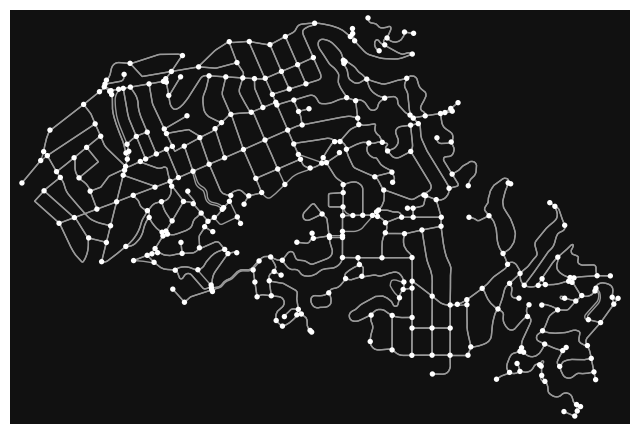

In [12]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Lerm-et-musset, France", network_type="drive")
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

### Preprocessing

In [13]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'load': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'load': 0, 'weight': 1, 'capacity': 8}


In [14]:
# G3=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
# G3=nx.DiGraph(G)
G3=G

In [15]:
len(max(list(nx.strongly_connected_components(G3)), key=len))/G3.number_of_nodes()

0.9914772727272727

In [16]:
# Get strongly connected component
G4 = max(list(nx.strongly_connected_components(G3)), key=len)
G4 = G3.subgraph(G4)

### Bla

In [ ]:
class Car_fleet(Base_car_fleet):
    @timeit
    def display(self, ax, edge_list=None):
        """
    Displays city (self.graph) and traffic (self.fleet).
        """
        node_c = get_dict(list(self.graph.nodes), self.get_loc(include_completed=False), self.get_arr(include_completed=False), 'r', 'g', 'grey')
        node_size = {node:Count(self.get_loc(include_completed=False))[node]**0.5*15 for node in list(self.graph.nodes)}
        if edge_list:
            if self.is_multi:
                edge_c = {(u,v,k):'y' if edge_data['weight']>2 else 'grey' for u,v,k,edge_data in list(self.graph.edges(keys=True,data=True))}
            else:
                edge_c = {(u,v):'y' if edge_data['weight']>2 else 'grey' for u,v,edge_data in list(self.graph.edges(data=True))}
            for edge in self.info:
                edge_c[edge]='r'
            edge_alpha = {(u,v,k):1 if self.rx_helper.nx_graph.has_edge(u,v,k) else 0. for u,v,k,edge_data in list(self.graph.edges(keys=True,data=True))}
            
        ox.plot.plot_graph(
                nx.MultiDiGraph(self.graph),
                ax=ax,          # Use the animation's axis
                show=False,     # Don't open a new window now
                close=False,    # Don't close the plot
                node_color=list(node_c.values()),
                node_size=list(node_size.values()),
                edge_alpha=list(edge_alpha.values()),
                edge_color=list(edge_c.values())
            )
        
    def get_path(self, node1, node2, weight) -> list: #Jamais None pck on bosse sur une seule composante
        if nx.has_path(self.rx_helper.nx_graph, node1, node2):
            return self.rx_helper.get_shortest_path(node1, node2, weight)
        elif nx.has_path(self.graph, node1, node2):
            path=nx.shortest_path(self.graph, node1, node2, weight)
            for k,u in enumerate(path, start=1):
                if not nx.is_path(self.rx_helper.nx_graph, path[:k]): #Oriented ?
                    break
            return path[:k-1]

    @timeit
    def update_fleet(self):
        """
    Updates car states and handles interactions during displacement.
        """
        for k,car in enumerate(self.fleet):
            if self.step>0:
                self.handle_interactions(car.old_loc, car.loc, -1, 1, op=operator.lt) # Update old edges
        
            if not car.completed:
                path = self.all_paths[car.loc][car.arr][0]
                if len(path)>1:
                    car.path=path
                    car.cost = self.get_cost(path, 'weight')
                    _, next_lane=self.select_min_weight_lane(path[0], path[1], 'weight')
                    next_weight=next_lane['weight']
                    if car.cost > 10000:
                        self.info.append((car.path[0], car.path[1]))                    
            
                    car.update_loc_and_path(next_weight)
                    # On supprime pas l'ancien état puisque deux voitures peuvent se suivre
                    self.edges_state[(car.loc, car.arr)]=self.check_edges_along_path(car.path)
                    self.handle_interactions(car.old_loc, car.loc, 1, 10000, op=operator.ge) # Update new edges
                else:
                    # Stay still
                    pass
            elif car.completed and car.old_loc!=car.loc: #Vient juste d'arriver
                car.old_loc=car.loc
                

    def prepare_attack(self, attack='deg', batch_size=5, number_steps=30):
        """
        * 'ebc' for edge betweenness centrality
        * 'rd' for random
        * 'deg' for max degree computed by extremities sum
        * 'xdeg' for max degree computed by extremities product
        * 'mindeg' for min degree computed by extremities sum
        * 'minxdeg' for min degree computed by extremities product
        """
        print ("Preparing attack...", end="\r")
        if attack=='ebc':
            rx_edges = feature_based_attack(self.rx_helper.rx_g.copy(), l=number_steps*batch_size, attack_name=attack)
            edges=[self.rx_helper.edge_rx_to_nx[rx_edge] for rx_edge in rx_edges]
        else:
            edges = feature_based_attack(self.graph.copy(), l=number_steps*batch_size, attack_name=attack, 
                                    #  igraph=ig.Graph.from_networkx(self.graph.copy())
                                    )
        self.rmvd_edges=[]
        self.to_rmv_edges = edges
        self.to_rmv_edges = list(it.batched(self.to_rmv_edges, n=batch_size))
        print ("Launching simulation", end="\r")


    def launch_attack(self, end_step=30):
        def _attack(u,v,k):
            if self.rx_helper.nx_graph.has_edge(u,v,k):
                edge_data=self.rx_helper.nx_graph[u][v][k]
                self.reset_edge(edge_data)
                edges_rmvd.append([(u,v,k), edge_data])
                self.rx_helper.remove_edge(u,v,k)
                
        if self.to_rmv_edges:
            if self.step<end_step:
                edges=self.to_rmv_edges.pop(0)
                edges_rmvd=[]
                for (u,v,k) in edges:
                    _attack(u,v,k)
                    _attack(v,u,k)
                self.rmvd_edges.append(edges_rmvd)

    def repair_attack(self, launch_step=30):
        if self.rmvd_edges:
            if self.step>launch_step:
                edges=self.rmvd_edges.pop(0)
                for (u,v,k), data in edges:
                    self.rx_helper.add_edge(u,v,k,data)

    def run(self, attack=True, repair=True):
        self.info=[]
        if not self.all_completed():
            if attack :
                self.launch_attack()
            if repair :
                self.repair_attack()
            self.calculate_paths(dist=3)
            self.update_fleet()
            self.step+=1


### Dynamique induite et update

91it [00:10, 14.69it/s]                        

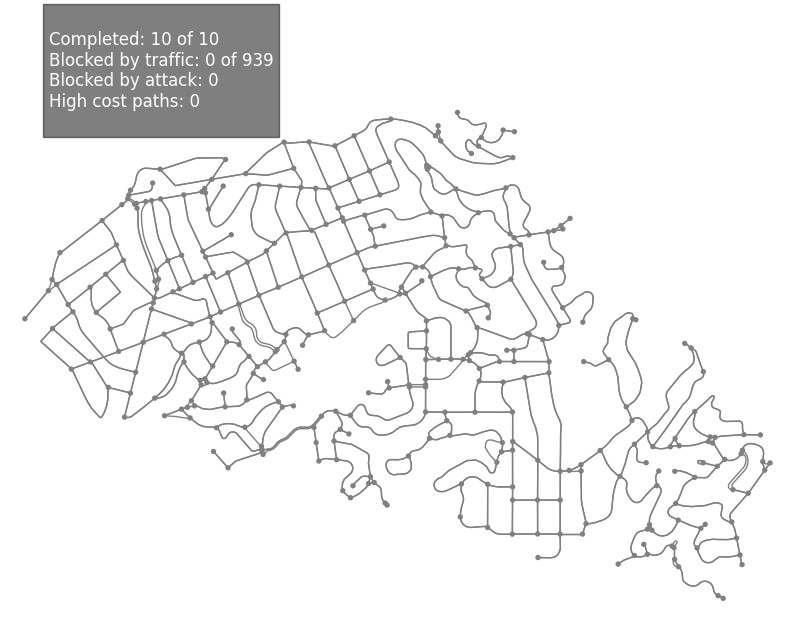

91it [00:18,  4.91it/s]


In [23]:
demand=Car_fleet(G4.copy(), size=2*10, replace=True)
demand.prepare_attack(attack='deg', batch_size=5)
frames=90
logging.info(f'__________________________________________________________________')

def update(frame):
    pbar.update(1)
    if demand.all_completed():
        return ax,
    
    ax.clear()
    if frame > 0:
        demand.run(attack=True)
    demand.display(ax=ax, edge_list=True)
    string=f'''
Completed: {sum(demand.get_completed())} of {demand.num_cars}
Blocked by traffic: {sum(demand.get_edge_blocked().values())} of {demand.graph.number_of_edges()}
Blocked by attack: {len(list(it.chain.from_iterable(demand.rmvd_edges)))}
High cost paths: {len(demand.info)}
'''
    ax.text(0.05, 0.95, string,
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5))
    return ax,

with tqdm(total=frames) as pbar:
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, update, frames=frames, interval=150, repeat=False)
    ani.save("ani.gif", writer='pillow')
    plt.show()
demand.end_test_load()

In [19]:
from folium import Map
import base64
from IPython.display import IFrame, display

def show_folium_safe(m : Map, height=500):
    """
    Displays a Folium map in a safe IFrame using Base64 encoding.
    This avoids "Trusted" errors, file path issues, and CSS leakage.
    """
    # 1. Get the raw HTML string of the map
    html_content = m.get_root().render()
    
    # 2. Encode the HTML to base64
    # This allows us to put the entire map "inside" the URL string
    encoded = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
    
    # 3. Create a Data URI
    data_uri = f"data:text/html;charset=utf-8;base64,{encoded}"
    
    # 4. Display the IFrame
    # We use width='100%' to fill the cell width, but the CSS is trapped inside
    display(IFrame(src=data_uri, width="100%", height=height))

In [20]:
# explore nodes and edges together in a single map
nodes, edges = ox.convert.graph_to_gdfs(demand.rx_helper.nx_graph)
node_c = get_dict(list(demand.rx_helper.nx_graph.nodes), demand.get_loc(include_completed=False), demand.get_arr(include_completed=False), 'r', 'g', 'grey')
node_size = {node:Count(demand.get_loc(include_completed=False))[node]**0.5*15 for node in list(demand.rx_helper.nx_graph.nodes)}
if demand.is_multi:
    edge_c = {(u,v,k):'y' if edge_data['weight']>2 else 'grey' for u,v,k,edge_data in list(demand.rx_helper.nx_graph.edges(keys=True,data=True))}
else:
    edge_c = {(u,v):'y' if edge_data['weight']>2 else 'grey' for u,v,edge_data in list(demand.rx_helper.nx_graph.edges(data=True))}
for edge in demand.info:
    edge_c[edge]='r'
edge_alpha = {(u,v,k):1 if demand.rx_helper.nx_graph.has_edge(u,v,k) else 0. for u,v,k,edge_data in list(demand.graph.edges(keys=True,data=True))}

m = edges.explore(color=list(edge_c.values()), tiles="cartodbdarkmatter")
map=nodes.explore(m=m, color=list(node_c.values()), marker_kwds={"radius": 3})
show_folium_safe(map)